### 5 Number summary and box plot

In [1]:
### Minimum Value, Max Value and the Median, Q1, Q3, IQR

import numpy as np 


In [2]:
lst_marks = [45,32,56,78,33,48,98,77,86,22,80,97,67,59,45]

minimum,Q1,median,Q3,maximum = np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])

In [3]:
minimum,Q1,median,Q3,maximum

(np.float64(22.0),
 np.float64(45.0),
 np.float64(59.0),
 np.float64(79.0),
 np.float64(98.0))

In [4]:
IQR = Q3 - Q1
IQR

np.float64(34.0)

In [5]:
lower_fence = Q1 - 1.5*(IQR)
higher_fence = Q3 + 1.5*(IQR)

print("Lower Fence : ",lower_fence)
print("Higher Fence : ",higher_fence)

Lower Fence :  -6.0
Higher Fence :  130.0


In [6]:
lst_marks = [45,32,56,78,33,48,98,77,86,22,80,97,67,59,45]


<Axes: >

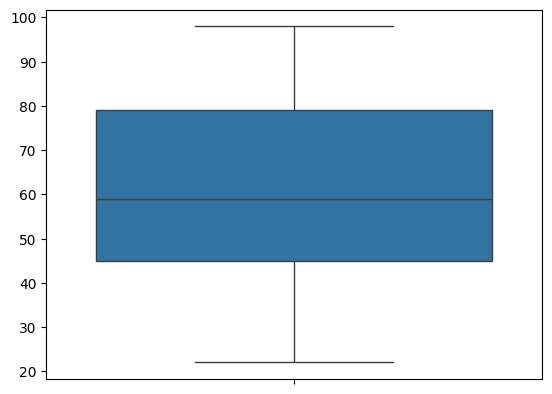

In [7]:
import seaborn as sns

sns.boxplot(lst_marks)

In [8]:
lst_marks = [-10,-29,45,32,56,78,33,48,98,77,86,22,80,97,67,59,45,170,232,220]


<Axes: >

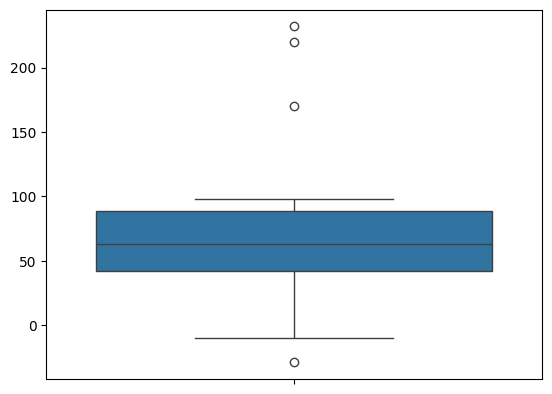

In [9]:
import seaborn as sns

sns.boxplot(lst_marks)

## From-scratch: IQR and Z-score detection, compared against library tooling

Both detection rules are a handful of arithmetic operations on a NumPy array — worth writing by
hand once before ever calling a library function that does the same thing. The IQR rule flags
anything outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`; the Z-score rule standardizes every value and
flags anything more than `thresh` standard deviations from the mean. `scipy.stats.zscore` computes
the exact same standardization, and `sklearn.preprocessing.RobustScaler` centers/scales using the
median and IQR internally — so both give a direct, checkable comparison point.

In [10]:
from scipy import stats
from sklearn.preprocessing import RobustScaler

arr = np.array(lst_marks, dtype=float)  # the version with [-10, -29, 170, 232, 220] added


def iqr_outliers(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (x < lower) | (x > upper), lower, upper


def zscore_outliers(x, thresh=3.0):
    mean, std = x.mean(), x.std(ddof=0)
    z = (x - mean) / std
    return np.abs(z) > thresh, z


mask_iqr, lower, upper = iqr_outliers(arr)
mask_z, manual_z = zscore_outliers(arr)

print("IQR fence:", (lower, upper))
print("IQR-flagged outliers:  ", arr[mask_iqr])
print("Z-score-flagged outliers (|z|>3):", arr[mask_z])
print()
print("manual z-scores match scipy.stats.zscore:", np.allclose(manual_z, stats.zscore(arr, ddof=0)))

rs = RobustScaler().fit(arr.reshape(-1, 1))
q1, q3 = np.percentile(arr, [25, 75])
print(f"RobustScaler center_ (median) = {rs.center_[0]}  |  np.median = {np.median(arr)}")
print(f"RobustScaler scale_  (IQR)    = {rs.scale_[0]}  |  manual Q3-Q1 = {q3 - q1}")


IQR fence: (np.float64(-28.125), np.float64(158.875))
IQR-flagged outliers:   [-29. 170. 232. 220.]
Z-score-flagged outliers (|z|>3): []

manual z-scores match scipy.stats.zscore: True
RobustScaler center_ (median) = 63.0  |  np.median = 63.0
RobustScaler scale_  (IQR)    = 46.75  |  manual Q3-Q1 = 46.75


## Failure mode: removing genuine extreme values loses real signal

The IQR/Z-score rules flag anything statistically unusual — they cannot distinguish a data-entry
error from a rare but *real* event. The experiment below builds a dataset where a linear
relationship genuinely holds all the way into the tail (a few points really do have large `x` and
proportionally large `y` — not corrupted, just rare), applies the IQR rule blindly, and refits a
linear regression with and without the flagged points removed.

In [11]:
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(0)
n = 200
# most x values cluster near 50; a handful are genuinely large (real rare events, not corrupted data)
x = np.concatenate([rng.normal(50, 10, n - 10), rng.uniform(150, 300, 10)])
true_slope, true_intercept = 2.0, 5.0
y = true_slope * x + true_intercept + rng.normal(0, 15, size=n)

mask_out, lo2, hi2 = iqr_outliers(x)
x_clean, y_clean = x[~mask_out], y[~mask_out]

full_model = LinearRegression().fit(x.reshape(-1, 1), y)
clean_model = LinearRegression().fit(x_clean.reshape(-1, 1), y_clean)

print(f"Points flagged as outliers by the IQR rule: {mask_out.sum()} / {n}")
print(f"True slope: {true_slope}")
print(f"Slope estimated on FULL data (genuine extremes kept):        {full_model.coef_[0]:.4f}")
print(f"Slope estimated after REMOVING IQR-flagged points:            {clean_model.coef_[0]:.4f}")
print(f"R^2 (full-data model, evaluated on all 200 points):            {full_model.score(x.reshape(-1, 1), y):.4f}")
print(f"R^2 (outlier-removed model, evaluated on the SAME all points): {clean_model.score(x.reshape(-1, 1), y):.4f}")


Points flagged as outliers by the IQR rule: 10 / 200
True slope: 2.0
Slope estimated on FULL data (genuine extremes kept):        2.0150
Slope estimated after REMOVING IQR-flagged points:            1.9126
R^2 (full-data model, evaluated on all 200 points):            0.9670
R^2 (outlier-removed model, evaluated on the SAME all points): 0.9644
